In [2]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

import time
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar

In [3]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0,IsNew32=False)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=10,adc_last_gap=10)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(20, 20,delay3=100)
chip.add_compiler("../compiler/code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 63533
正在编译文件:  ../compiler/code/read_point3_from_col.txt
正在编译文件:  ../compiler/code/read_point3_from_row.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


In [ ]:
# set_good_device_file_name = "../data/good_device/cond_500_r8.npy"
# reset_good_device_file_name = "../data/good_device/cond_200_r8.npy"

# 1.set操作

In [ ]:
# pos = (0,256,0,256)
# chip.write_point3(*pos,write_voltage=3,tg=1.6,pulse_width=1e-6,set_device=True)

In [ ]:
# pos = (0,256,0,256)
# voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
# voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
# cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
# plot_cond(cond,title="cond",vmin=0,vmax=1500)

# 2.reset操作

In [ ]:
# # 对某一块区域内的点进行reset
# pos = (0,256,0,256)
# chip.write_point3(*pos,write_voltage=3,tg=1.6,pulse_width=1e-6,set_device=False)

In [ ]:
def Reset(need_read,write_times,start_v,delta_v,tg,threshold,reset_pulse_width,read_type=2,sub_base=False,vmax=1000,plot_cond=None):
    voltage_base = np.zeros((256,256))
    voltage = np.zeros((256,256))
    cond_sub_base = None
    for i in range(write_times):
        print(f"write_time = {i}")
        v = start_v+i*delta_v
        if read_type == 2:
            if sub_base:
                voltage_base[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)[need_read]
            voltage[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)[need_read]
        elif read_type == 3:
            pos = (0,256,0,256)
            if sub_base:
                voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
            voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
        if sub_base:
            cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
        else:
            cond_sub_base = chip.voltage_to_cond(voltage)

        condition_reset = cond_sub_base>threshold
        need_read = condition_reset
        if plot_cond:
            plot_cond(cond_sub_base,title=f"v={v:.2f}-needReset={np.sum(condition_reset)}",vmax=vmax)

        chip.write_point2(crossbar=condition_reset,write_voltage=v,tg=tg,pulse_width=reset_pulse_width,set_device=False)

In [ ]:
Reset(need_read = np.ones((256,256),dtype=bool),write_times=41,start_v=1,delta_v=0.05,tg=5,threshold=150,
      reset_pulse_width=100e-6,read_type=2,sub_base=True,plot_cond=plot_cond,vmax=1400)

In [ ]:
pos = (0,256,0,256)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
print(np.sum(cond<200))
np.save(reset_good_device_file_name,cond<200)

In [ ]:
# cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
# plot_cond(cond,vmin=0,vmax=500)

# interval = 5
# bin_edges = np.linspace(0, 1000, int(2000/interval)+1)  
# data = cond.flatten()
# counts, bin_edges, _ = plt.hist(data, bins=bin_edges, color='blue', alpha=0.7, edgecolor='None')

# 3.Forming器件

In [ ]:
# # 对某一块区域内的点进行set
# pos = (0,256,0,256)
# chip.write_point3(*pos,write_voltage=3,tg=1.6,pulse_width=1e-6,set_device=True)

In [ ]:
def Forming(write_times,write_voltage,start_tg,delta_tg,threshold,set_pulse_width,read_type=2,sub_base=False):
    need_read = np.ones((256,256),dtype=bool)
    voltage_base = np.zeros((256,256))
    voltage = np.zeros((256,256))
    cond_sub_base = None
    for i in range(write_times):
        print(f"write_time = {i}")
        tg = start_tg+i*delta_tg
        if read_type == 2:
            if sub_base:
                voltage_base[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)[need_read]
            voltage[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)[need_read]
        elif read_type == 3:
            pos = (0,256,0,256)
            if sub_base:
                voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
            voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
        if sub_base:
            cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
        else:
            cond_sub_base = chip.voltage_to_cond(voltage)



        condition_set = cond_sub_base<threshold
        need_read = condition_set

        plot_cond(cond_sub_base,title=f"tg={tg:.2f}-needForming={np.sum(condition_set)}",vmax=1200)
        # if i==0:
        #     chip.write_point2(crossbar=condition_set,write_voltage=5,tg=2.5,pulse_width=1e-6,set_device=False)
        # set的点
        chip.write_point2(crossbar=condition_set,write_voltage=write_voltage,tg=tg,pulse_width=set_pulse_width,set_device=True)

In [ ]:
chip.ps.set_time_out(10)
for i in range(1):
    need_read = np.ones((256,256),dtype=bool)
    Forming(write_times=41,write_voltage=5,start_tg=1,delta_tg=0.05,threshold=600,set_pulse_width=100e-6,read_type=2,sub_base=True)

In [ ]:
pos = (0,256,0,256)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
print(np.sum(cond>500))
np.save(set_good_device_file_name,cond>500)

# 3.寻找好的区域

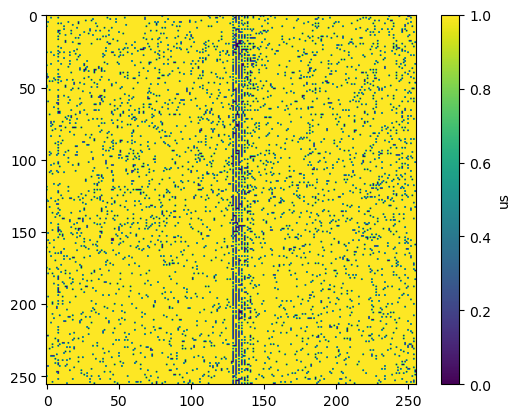

In [5]:
cond_200 = np.load(reset_good_device_file_name)
cond_500 = np.load(set_good_device_file_name)
good_cond = cond_200&cond_500
plot_cond(good_cond,vmax=1)

60821


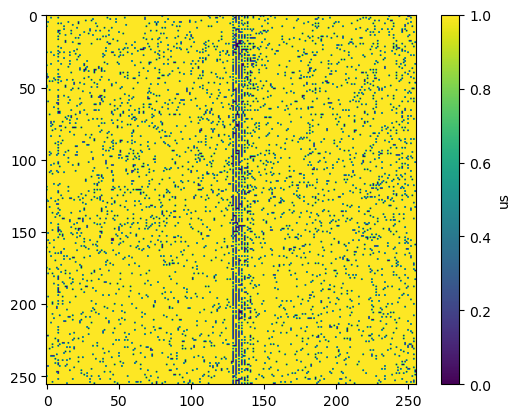

In [6]:
# 可以选最大的0-100行里面的5列
col = np.sum(good_cond,axis=0)
col = np.argsort(col)
col = np.sort(col)

row = good_cond[:, col]
row = np.sum(row,axis=1)
row = np.argsort(row)#[-100:]
row = np.sort(row)#[:100]


sub_matrix = good_cond[np.ix_(row, col)]
print(np.sum(sub_matrix))
plot_cond(sub_matrix,vmax=1)


In [7]:
def find_good_device(row,col,rownum,colnum,good_cond,cnt=10):
    select_row,select_col=row[:rownum],col[:colnum]
    rowtmp,coltmp=row[rownum:],col[colnum:]
    
    ansrow=[]
    anscol=[]

    for n in range(cnt):
        flag = False

        
        # 遍历所有选择的行，替换
        for j in select_row:
            k=j
            for i in rowtmp:
                if np.sum(good_cond[i,select_col])>np.sum(good_cond[k,select_col]):
                    k=i
            if k!=j:
                rowtmp.remove(k)
                rowtmp.append(j)
                flag=True
            ansrow.append(k)
        
        select_row=ansrow
        ansrow=[]

        # 遍历所有选择的列，替换
        for j in select_col:
            k=j
            for i in coltmp:
                if np.sum(good_cond[select_row,i])>np.sum(good_cond[select_row,k]):
                    k=i
            if k!=j:
                coltmp.remove(k)
                coltmp.append(j)
                flag=True
            anscol.append(k)
        
        select_col=anscol
        anscol=[]

        if not flag:
            break
        # print(n)
    return select_row,select_col

[ 55  64  76  79  82  84  85  86  92  93  96  98 101 103 105 106 107 110
 113 114 116 118 123 124 133 140 166 171 172 174 181 187 193 197 201 205
 210 214 215 219 220 223 224 228 232 244 245 251 253]
[  0   1   7  10  11  12  13  14  15  16  17  18  21  23  26  28  29  32
  34  37  38  40  43  47  49  50  53  62  68  70  78  81  93  96  97 100
 109 120 158 159 164 172 190 191 193 195 221 233 237]
2401


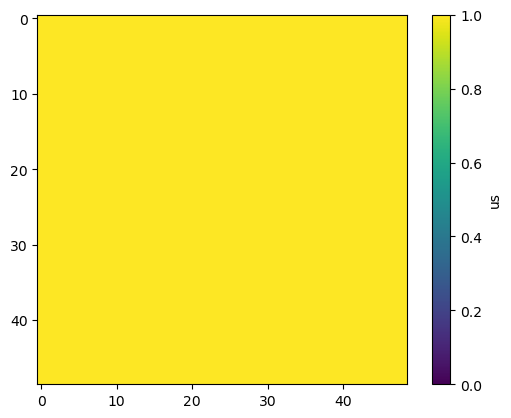

In [14]:
row=[i for i in range(50,256)]
col=[i for i in range(256)]
select_row=[]
ansrow,anscol=find_good_device(row,col,49,49,good_cond=good_cond)

sub_matrix = good_cond[np.ix_(ansrow, anscol)]
print(np.sort(ansrow))
print(np.sort(anscol))
print(np.sum(sub_matrix))
plot_cond(sub_matrix,vmax=1)

In [12]:
np.savez("../data/hnn/hnn_weight_pos_r8_7_7",row=np.sort(ansrow),col=np.sort(anscol))
# a=np.load("../data/svm/svm_weight_pos.npz")
# print(a["row"])

In [ ]:
print(np.ix_(row,col)[1])

In [ ]:
pos0 = np.zeros((256,256))
pos0[np.ix_(row,col)]=1
plot_cond(pos0,vmax=1)

good_device = np.load("../data/good_point_100_100_1_4.npy")
print(good_device[1])
pos1 = np.zeros((256,256))
pos1[np.ix_(good_device[0],good_device[1])]=1
plot_cond(pos1,vmax=1)

print(np.sum((pos0>0)&(pos1>0)))
plot_cond((pos0>0.5)&(pos1>0.5),vmax=1)